In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt

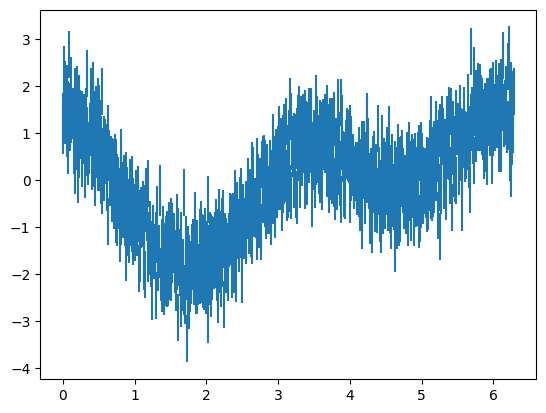

In [2]:
N_SINE = 2
x = jnp.linspace(0,2*jnp.pi,1000)
phases = jax.random.uniform(jax.random.key(0), minval=0, maxval=2*jnp.pi, shape=(N_SINE,))
frequencies = jnp.arange(1, N_SINE+1)
y_data = jnp.sin(frequencies[None] * x[...,None] + phases[None]).sum(1)
y_error = 0.5
y_data = jax.random.normal(jax.random.key(0),shape=y_data.shape)*y_error + y_data
plt.errorbar(x,y_data,y_error,fmt='none');

In [3]:
@jax.jit
def U(q, y_data, x):
  frequencies = q[0::2]
  phases = q[1::2]
  y_model = jnp.sin(frequencies[None] * x[...,None] + phases[None]).sum(1)
  loglike = - 0.5 * ((y_data - y_model)**2 / y_error).sum()
  logprior = 0.5 * q.shape[0] * (jnp.log(1/2) + jnp.log(1/2*jnp.pi))
  return - logprior - loglike

In [4]:
β = 1

In [5]:
def general_DHMC(q, n, N_sample, Tmin, Tmax, seed=0, m=1, m_n=1):
  samples = []
  key = jax.random.key(seed)
  for i in range(N_sample):
    key, _ = jax.random.split(key)
    p = jax.random.normal(key, shape=q.shape) * jnp.sqrt(m)
    p_n = jax.random.laplace(key, shape=(1,)) * m_n
    #print(p_n)
    T = jax.random.uniform(key, minval=Tmin, maxval=Tmax)
    q_tilde, p_tilde, n_tilde, p_n_tilde = DDHMC_step(q, p, n, p_n, T, key, m, m_n)
    q, n = q_tilde, n_tilde
    samples.append(q)
  return samples

In [6]:
def K_n(p_n, m_n):
  return jnp.abs(p_n) / m_n

In [7]:
grad_U = jax.grad(U)

In [69]:
def DDHMC_step(q, p, n, p_n, T, key, m, m_n, N_iter=3):
  """Perform one iteration of Discretized Discontinuous Hamiltonian Monte Carlo"""
  Δt = T / N_iter
  for i in range(N_iter):
    q += 0.5 * Δt * p / m
    p -= 0.5 * Δt * grad_U(q, y_data, x)
    δn = Δt / m_n * jnp.sign(p_n)
    N = jnp.floor(n)
    if n + δn >= N + 1 or n + δn < N:
      #print('transdimensional step')
      if n + δn >= N + 1:
        #print('add')
        p_new = jax.random.normal(key, shape=(2,)) * m / β
        q_new = jax.random.uniform(key, shape=(2,)) * jnp.array([2, 2*jnp.pi]) + jnp.array([0.5,0])
        p_tilde, q_tilde = jnp.concatenate((p, p_new)), jnp.concatenate((q, q_new))
      else:
        #print('delete')
        p_tilde = p[:-2]
        q_tilde = q[:-2]
      δH = U(q_tilde, y_data, x) - U(q, y_data, x) + (q.shape[0] - q_tilde.shape[0]) / 2 * jnp.log(1/2 * 1/2/jnp.pi) / β
      #print(K_n(p_n, m_n), δH)
      if K_n(p_n, m_n) >= δH:
        #print('accepted', K_n(p_n, m_n), δH)
        q, p = q_tilde, p_tilde
        p_n -= jnp.sign(p_n) * m_n * δH
        n += δn
      else:
        #print('rejected', K_n(p_n, m_n), δH)
        p_n *= -1
    p -= 0.5 * Δt * grad_U(q, y_data, x)
    q += 0.5 * Δt * p / m
  return q, p, n, p_n

In [162]:
q_initial = jnp.ones(4).astype(jnp.float64)#jnp.array([frequencies[0],phases[0],frequencies[1],phases[1]])#jnp.array([2.,2.]*3)#,2.,2.])
n_initial = 2.1
N_sample = 10000
Tmin = 0.0275
Tmax = 0.0525
seed = 0
m = 1
m_n = 0.01
samples = general_DHMC(q_initial, n_initial, N_sample, Tmin, Tmax, seed=seed, m=m, m_n=m_n)

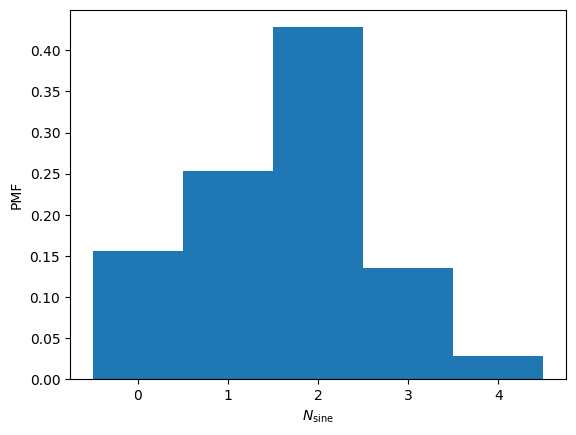

In [169]:
plt.hist(jnp.array(lengths), bins=jnp.arange(6), align='left', density=True)
plt.xlabel(r'$N_\text{sine}$')
plt.ylabel('PMF')
plt.xticks(jnp.arange(5));

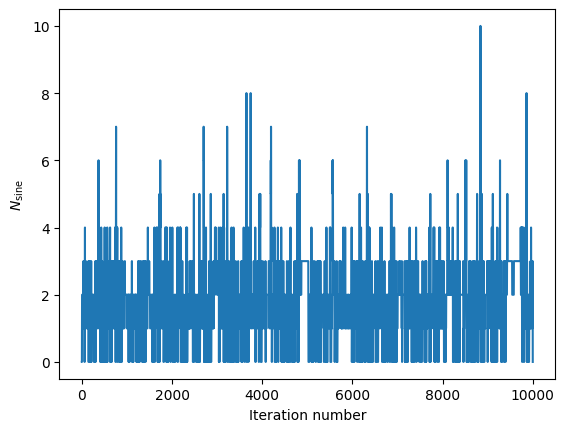

In [163]:
lengths = [len(sample)//2 for sample in samples]
plt.plot(lengths)
plt.xlabel('Iteration number')
plt.ylabel(r'$N_\text{sine}$');

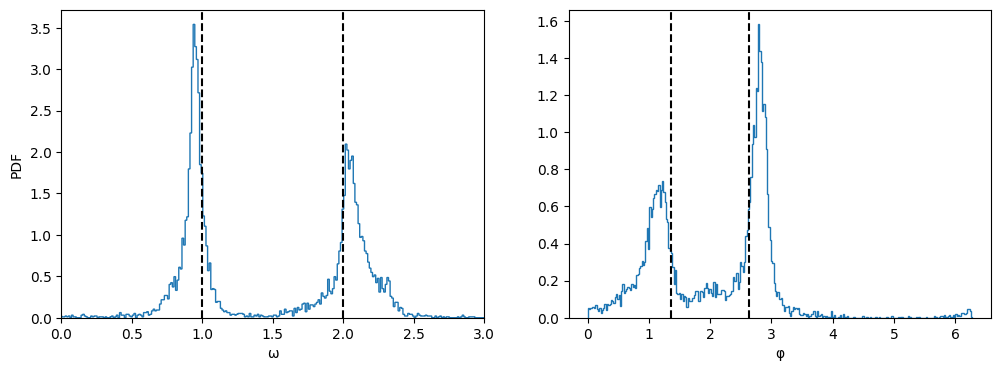

In [184]:
samples_with2sines = jnp.array([sample for sample in samples if len(sample) == 4]).flatten()
fig, ax = plt.subplots(1,2,figsize=(12,4))
plt.sca(ax[0])
plt.xlim(0,3)
plt.hist(jnp.concatenate((samples_with2sines[::4], samples_with2sines[2::4])), bins=1000, histtype='step', density=True)
plt.axvline(1, color='black', linestyle='dashed')
plt.axvline(2, color='black', linestyle='dashed')
plt.xlabel('ω')
plt.ylabel('PDF')
plt.sca(ax[1])
plt.hist(jnp.concatenate((samples_with2sines[1::4]%(2*jnp.pi), samples_with2sines[3::4]%(2*jnp.pi))), bins=300, histtype='step', density=True)
plt.axvline(phases[0], color='black', linestyle='dashed')
plt.axvline(phases[1], color='black', linestyle='dashed')
plt.xlabel('φ')
plt.show()